In [1]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.0 MB/s eta 0:00:0000:0100:01


In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt
import os

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
dataset_path = "/kaggle/input/hardhat-vest-dataset-v3/images"
labels_path = "/kaggle/input/hardhat-vest-dataset-v3/labels"

folder_img = ["test", "train", "val"]
total_images = 0

for img in folder_img:
    count = len(os.listdir(f"{dataset_path}/{img}"))
    print(f"{img} image: {count}")
    total_images += count

print("=" * 20)
print("Total Images :", total_images)


test image: 2455
train image: 17248
val image: 2438
Total Images : 22141


In [4]:
folder_labels = ["train", "val", "test"]
total_labels = 0

for labels in folder_labels:
    count = len(os.listdir(f"{labels_path}/{labels}"))
    print(f"{labels} labels:{count}")
    total_labels += count

print("=" * 20)
print("Total labels:", total_labels)
    

train labels:17248
val labels:2438
test labels:2455
Total labels: 22141


In [5]:
if total_images == total_labels:
    print("Same Data")
else:
    print("Diffrent")

Same Data


In [6]:
yaml_content = """
path: /kaggle/input/hardhat-vest-dataset-v3
train: images/train
val: images/val
nc: 3
names: ['hardhat', 'vest', 'person']
"""

with open('hardhat.yaml', 'w') as f:
    f.write(yaml_content) 

In [10]:
model = YOLO('yolo26s.pt') 
results = model.train(data='hardhat.yaml', 
                      epochs=20,
                      batch=16,
                      imgsz=640,
                      patience=10)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=hardhat.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, 

In [11]:
metrics = model.val()

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO26s summary (fused): 122 layers, 9,466,341 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 350.4±276.5 MB/s, size: 207.6 KB)
val: Scanning /kaggle/input/hardhat-vest-dataset-v3/labels/val... 2438 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2438/2438 627.2it/s 3.9s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/hardhat-vest-dataset-v3/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 153/153 6.5it/s 23.5s0.1s
                   all       2438      21032      0.869      0.843      0.888      0.567
               hardhat       1782       6586      0.924       0.88      0.932      0.637
                  vest        406        870      0.798      0.743      0.817      0.554
                person        712      13576      0.885      0.908      0.

In [15]:
import os
from glob import glob

test_images = glob(f"{dataset_path}/test/*")[:5]

results = model.predict(
    source=test_images,
    save=True,
    verbose=False
)

Results saved to /kaggle/working/runs/detect/predict


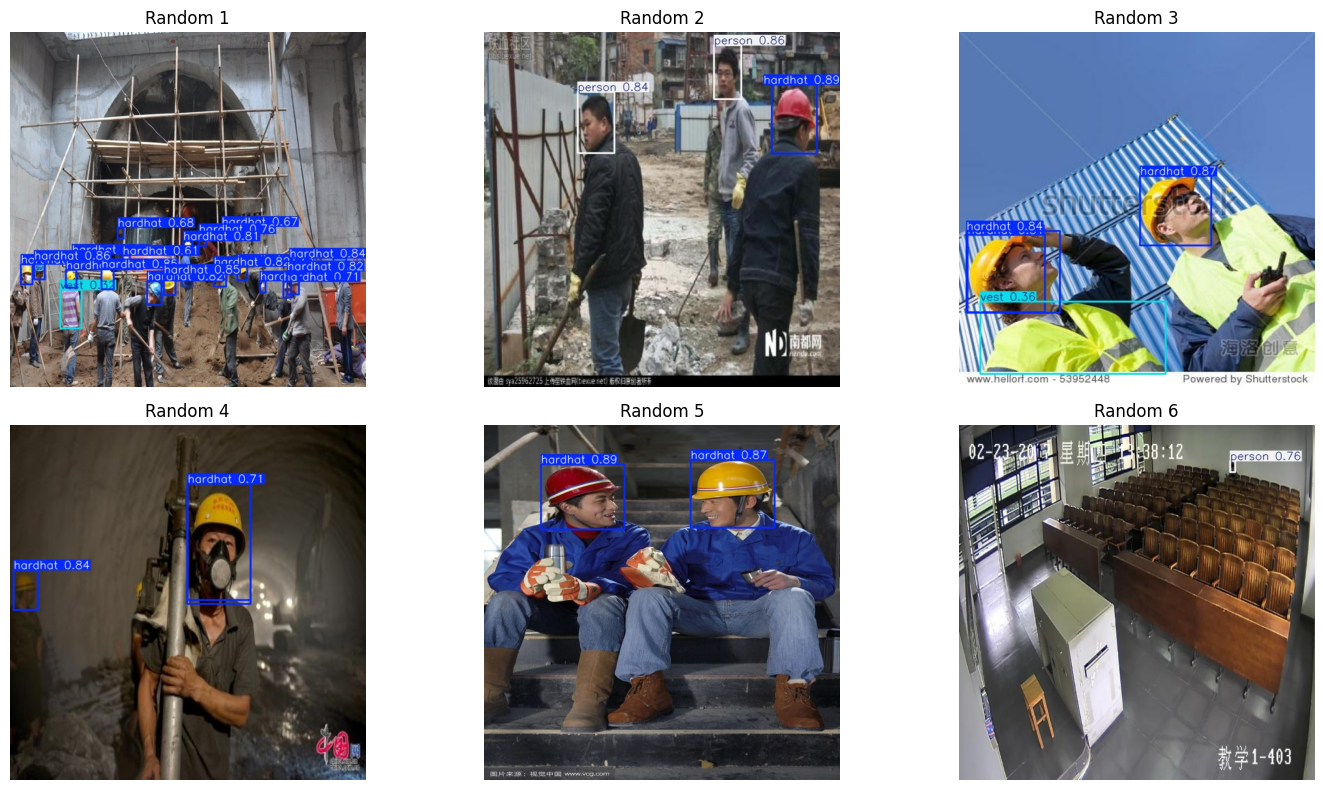

In [20]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob
import os
import random


predict_folders = sorted(glob.glob('runs/detect/predict*'))
latest_folder = predict_folders[-1]
all_images = glob.glob(os.path.join(latest_folder, '*.jpg'))


num_samples = min(6, len(all_images))
sampled_images = random.sample(all_images, num_samples)

plt.figure(figsize=(15, 8))
columns = 3
rows = (num_samples + columns - 1) // columns

for i, img_path in enumerate(sampled_images):
    img = mpimg.imread(img_path)
    plt.subplot(rows, columns, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Random {i+1}")

plt.tight_layout()
plt.show()
